<a href="https://colab.research.google.com/github/lukazsw/Machine-Learning-2025L/blob/main/lw430257_homework06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Praca Domowa: LAB06_TREE_METHODS

# Autor: Łukasz Wysocki

W tym notebooku analizuję trzy sformułowania kryterium wyboru podziału w regresyjnych drzewach CART:

1. lokalną minimalizację RSS,
2. maksymalizację przyrostu RSS,
3. minimalizację całkowitego RSS.

Celem jest:
- sprawdzenie, które z tych sformułowań są równoważne,
- podanie krótkiego dowodu równoważności lub kontrprzykładu,
- zaprojektowanie eksperymentu pozwalającego ustalić, które kryterium stosuje `DecisionTreeRegressor` z biblioteki `scikit-learn`.

## 1. Analiza teoretyczna

Najpierw porównam trzy kryteria wyboru podziału:

1. lokalną minimalizację RSS,
2. maksymalizację spadku RSS,
3. minimalizację całkowitego RSS po wykonaniu jednego nowego podziału.

Chcę odpowiedzieć na dwa pytania:

- czy lokalna minimalizacja RSS i maksymalizacja spadku RSS są równoważne,
- czy minimalizacja całkowitego RSS daje ten sam wybór podziału, czy może prowadzić do innego wyniku.

### 1.1. Relacja między lokalną minimalizacją RSS a maksymalizacją spadku RSS

**Wniosek:** te dwa kryteria są równoważne tylko wtedy, gdy **ustalimy rodzica** `Parent`.  
Gdy wolno wybierać także `Parent`, **nie muszą być równoważne**.

Dla ustalonego węzła `Parent` mamy:

$$
\text{RSS gain} = \text{RSS(Parent)} - \text{RSS(children)}.
$$

Ponieważ dla ustalonego `Parent` wartość $\text{RSS(Parent)}$ jest stała, to:

$$
\arg\min_{X_j,t} \text{RSS(children)}
=
\arg\max_{X_j,t} \left( \text{RSS(Parent)} - \text{RSS(children)} \right).
$$

Zatem dla **ustalonego rodzica** lokalna minimalizacja RSS i maksymalizacja spadku RSS dają dokładnie ten sam wybór cechy i progu.

Sytuacja zmienia się wtedy, gdy optymalizujemy po całej trójce $(Parent, X_j, t)$.

- Kryterium 1 minimalizuje tylko
$$
\text{RSS(children)}.
$$

- Kryterium 2 maksymalizuje
$$
\text{RSS(Parent)} - \text{RSS(children)}.
$$

Jeżeli porównujemy różne węzły `Parent`, to wartości $\text{RSS(Parent)}$ mogą być różne. Wtedy odejmowanie $\text{RSS(Parent)}$ przestaje być nieistotną stałą, więc oba kryteria mogą wskazać różne splity.

Czyli:

- **dla ustalonego `Parent`**: kryteria są równoważne,
- **gdy wybieramy również `Parent`**: kryteria mogą dawać różne wyniki.

### 1.2. Kontrprzykład: przy wyborze także rodzica kryteria 1 i 2 mogą dawać różne wyniki

Rozważmy częściowo zbudowane drzewo z dwoma liśćmi: $P_1$ i $P_2$.

Niech:

- w liściu $P_1$ wartości targetu będą równe $[0, 10, 10]$,
- w liściu $P_2$ wartości targetu będą równe $[0, 0, 100, 100]$.

Załóżmy, że rozważamy po jednym kandydacie splitu w każdym liściu:

- dla $P_1$: podział na $[0]$ oraz $[10,10]$,
- dla $P_2$: podział na $[0,0,100]$ oraz $[100]$.

Wtedy:

#### Liść $P_1$

Średnia w $P_1$ wynosi

$$
\bar y_{P_1} = \frac{0+10+10}{3} = \frac{20}{3}.
$$

RSS rodzica:

$$
\text{RSS}(P_1)
=
\left(0-\frac{20}{3}\right)^2
+
\left(10-\frac{20}{3}\right)^2
+
\left(10-\frac{20}{3}\right)^2
=
\frac{200}{3}.
$$

Po splicie obie grupy są stałe, więc:

$$
\text{RSS(children of }P_1\text{)} = 0.
$$

Zysk RSS:

$$
\text{gain}(P_1) = \frac{200}{3} - 0 = \frac{200}{3}.
$$

#### Liść $P_2$

Średnia w $P_2$ wynosi

$$
\bar y_{P_2} = \frac{0+0+100+100}{4} = 50.
$$

RSS rodzica:

$$
\text{RSS}(P_2)
=
(0-50)^2 + (0-50)^2 + (100-50)^2 + (100-50)^2
=
10000.
$$

Po splicie na $[0,0,100]$ oraz $[100]$ dostajemy:

- dla grupy $[0,0,100]$ średnia wynosi $\frac{100}{3}$,
- jej RSS wynosi

$$
\left(0-\frac{100}{3}\right)^2
+
\left(0-\frac{100}{3}\right)^2
+
\left(100-\frac{100}{3}\right)^2
=
\frac{20000}{3},
$$

- dla grupy $[100]$ RSS wynosi $0$.

Zatem:

$$
\text{RSS(children of }P_2\text{)} = \frac{20000}{3}.
$$

Zysk RSS:

$$
\text{gain}(P_2)
=
10000 - \frac{20000}{3}
=
\frac{10000}{3}.
$$

#### Porównanie

Kryterium 1 (lokalna minimalizacja RSS) wybiera split z mniejszym RSS w dzieciach:

$$
0 < \frac{20000}{3},
$$

więc wybiera **$P_1$**.

Kryterium 2 (maksymalizacja spadku RSS) wybiera split z większym zyskiem:

$$
\frac{10000}{3} > \frac{200}{3},
$$

więc wybiera **$P_2$**.

To pokazuje, że gdy wolno wybierać także `Parent`, kryteria 1 i 2 **nie są równoważne**.

### 1.3. Relacja między minimalizacją całkowitego RSS a pozostałymi kryteriami

**Wniosek:** minimalizacja całkowitego RSS jest równoważna **maksymalizacji spadku RSS**, ale nie jest równoważna **lokalnej minimalizacji RSS**, gdy wolno wybierać także `Parent`.

Niech aktualne drzewo $T$ ma liście:

$$
L_1, L_2, \dots, L_K.
$$

Załóżmy, że rozważamy split liścia $P$ według cechy $X_j$ i progu $t$. Po takim splicie wszystkie liście poza $P$ pozostają bez zmian. Zmienia się tylko to, że liść $P$ zostaje zastąpiony przez dwa nowe liście.

Dlatego całkowity RSS nowego drzewa można zapisać jako:

$$
\text{TotalRSS}\bigl(T(P,X_j,t)\bigr)
=
\sum_{L \neq P} \text{RSS}(L)
+
\text{RSS(children of }P\text{)}.
$$

Jednocześnie całkowity RSS starego drzewa wynosi:

$$
\text{TotalRSS}(T)
=
\sum_{L \neq P} \text{RSS}(L)
+
\text{RSS}(P).
$$

Odejmując stronami dostajemy:

$$
\text{TotalRSS}\bigl(T(P,X_j,t)\bigr)
=
\text{TotalRSS}(T)
-
\text{RSS}(P)
+
\text{RSS(children of }P\text{)}.
$$

Ponieważ $\text{TotalRSS}(T)$ jest stałe dla aktualnego drzewa, minimalizacja całkowitego RSS jest równoważna minimalizacji wyrażenia

$$
-\text{RSS}(P) + \text{RSS(children of }P\text{)},
$$

czyli równoważnie maksymalizacji

$$
\text{RSS}(P) - \text{RSS(children of }P\text{)}.
$$

To jest dokładnie kryterium **maksymalizacji spadku RSS**.

Zatem:

- kryterium 2 i kryterium 3 są równoważne,
- kryterium 1 i kryterium 3 nie są równoważne, jeśli można wybierać także `Parent`,
- jeśli `Parent` jest ustalony, wtedy wszystkie trzy kryteria prowadzą do tego samego wyboru $X_j$ i $t$.

### 1.4. Podsumowanie części teoretycznej

Ostatecznie otrzymujemy następujące wnioski:

1. **Kryterium 1 i kryterium 2**:
   - są równoważne, gdy `Parent` jest ustalony,
   - nie muszą być równoważne, gdy wybieramy także `Parent`.

2. **Kryterium 2 i kryterium 3**:
   - są równoważne.

3. **Kryterium 1 i kryterium 3**:
   - są równoważne tylko dla ustalonego `Parent`,
   - w ogólności nie muszą być równoważne.

To znaczy, że jeśli implementacja drzewa na każdym kroku wybiera globalnie najlepszy kolejny split w całym aktualnym drzewie, to powinna być zgodna z:
- **maksymalizacją spadku RSS**,
- równoważnie: **minimalizacją całkowitego RSS po wykonaniu jednego nowego podziału**.

W następnej części sprawdzę empirycznie, czy tak właśnie działa `DecisionTreeRegressor` ze `scikit-learn`.

## 2. Weryfikacja empiryczna

Teraz przygotuję mały sztuczny zbiór danych, który pozwoli odróżnić:

- lokalną minimalizację RSS,
- maksymalizację spadku RSS,
- minimalizację całkowitego RSS.

Celem eksperymentu jest sprawdzenie, które kryterium jest zgodne z działaniem `DecisionTreeRegressor` z `scikit-learn`.

Żeby uchwycić moment wyboru kolejnego podziału, użyję **pre-prunningu**, tak aby budowa drzewa zatrzymała się w kontrolowanym momencie i dało się jednoznacznie porównać możliwe decyzje algorytmu.

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor, plot_tree

In [12]:
def rss(y):
    """Return residual sum of squares around the sample mean."""
    y = np.asarray(y, dtype=float)
    return np.sum((y - np.mean(y)) ** 2)


def candidate_thresholds(x):
    """Return midpoints between consecutive unique sorted values."""
    x_sorted = np.unique(np.sort(np.asarray(x, dtype=float)))
    if len(x_sorted) < 2:
        return np.array([])
    return (x_sorted[:-1] + x_sorted[1:]) / 2.0


def split_rss(x, y, threshold):
    """Return RSS of left child, right child and their sum for one split."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    left_mask = x <= threshold
    right_mask = ~left_mask

    if left_mask.sum() == 0 or right_mask.sum() == 0:
        return np.inf, np.inf, np.inf

    left_rss = rss(y[left_mask])
    right_rss = rss(y[right_mask])
    return left_rss, right_rss, left_rss + right_rss


def best_local_split(x, y):
    """Find the split minimizing children RSS inside one fixed parent."""
    thresholds = candidate_thresholds(x)

    best_threshold = None
    best_children_rss = np.inf

    for threshold in thresholds:
        _, _, children_rss = split_rss(x, y, threshold)
        if children_rss < best_children_rss:
            best_children_rss = children_rss
            best_threshold = threshold

    return best_threshold, best_children_rss


def print_node_summary(name, y_parent, y_left, y_right):
    """Print parent RSS, children RSS and RSS gain for one candidate split."""
    parent_rss = rss(y_parent)
    children_rss = rss(y_left) + rss(y_right)
    gain = parent_rss - children_rss

    print(f"{name}:")
    print(f"  parent RSS   = {parent_rss:.6f}")
    print(f"  children RSS = {children_rss:.6f}")
    print(f"  RSS gain     = {gain:.6f}")

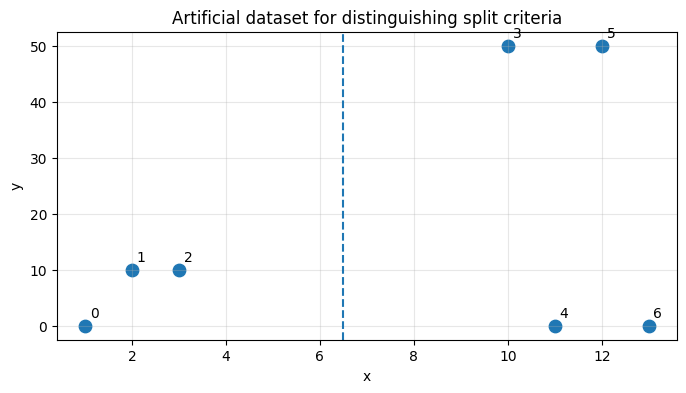

x = [ 1.  2.  3. 10. 11. 12. 13.]
y = [ 0. 10. 10. 50.  0. 50.  0.]


In [13]:
# Artificial 1D dataset designed to separate the criteria
x = np.array([1, 2, 3, 10, 11, 12, 13], dtype=float)
y = np.array([0, 10, 10, 50, 0, 50, 0], dtype=float)

X = x.reshape(-1, 1)

plt.figure(figsize=(8, 4))
plt.scatter(x, y, s=80)

for i, (x_i, y_i) in enumerate(zip(x, y)):
    plt.text(x_i + 0.1, y_i + 1.5, str(i), fontsize=10)

plt.axvline(6.5, linestyle="--")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Artificial dataset for distinguishing split criteria")
plt.grid(True, alpha=0.3)
plt.show()

print("x =", x)
print("y =", y)

In [14]:
# Check all candidate splits in the root node
root_thresholds = candidate_thresholds(x)

print("Candidate root splits:\n")
for threshold in root_thresholds:
    left_mask = x <= threshold
    right_mask = x > threshold

    left_y = y[left_mask]
    right_y = y[right_mask]

    parent_rss = rss(y)
    children_rss = rss(left_y) + rss(right_y)
    gain = parent_rss - children_rss

    print(f"threshold = {threshold:.1f}")
    print(f"  left y        = {left_y}")
    print(f"  right y       = {right_y}")
    print(f"  children RSS  = {children_rss:.6f}")
    print(f"  RSS gain      = {gain:.6f}")
    print()

best_root_threshold, best_root_children_rss = best_local_split(x, y)

print("Best root split:")
print(f"  threshold     = {best_root_threshold:.1f}")
print(f"  children RSS  = {best_root_children_rss:.6f}")

Candidate root splits:

threshold = 1.5
  left y        = [0.]
  right y       = [10. 10. 50.  0. 50.  0.]
  children RSS  = 2800.000000
  RSS gain      = 342.857143

threshold = 2.5
  left y        = [ 0. 10.]
  right y       = [10. 50.  0. 50.  0.]
  children RSS  = 2730.000000
  RSS gain      = 412.857143

threshold = 6.5
  left y        = [ 0. 10. 10.]
  right y       = [50.  0. 50.  0.]
  children RSS  = 2566.666667
  RSS gain      = 576.190476

threshold = 10.5
  left y        = [ 0. 10. 10. 50.]
  right y       = [ 0. 50.  0.]
  children RSS  = 3141.666667
  RSS gain      = 1.190476

threshold = 11.5
  left y        = [ 0. 10. 10. 50.  0.]
  right y       = [50.  0.]
  children RSS  = 2970.000000
  RSS gain      = 172.857143

threshold = 12.5
  left y        = [ 0. 10. 10. 50.  0. 50.]
  right y       = [0.]
  children RSS  = 2800.000000
  RSS gain      = 342.857143

Best root split:
  threshold     = 6.5
  children RSS  = 2566.666667


In [15]:
# Analyze the second split after fixing the root split at 6.5
root_threshold = 6.5

left_mask = x <= root_threshold
right_mask = x > root_threshold

x_left, y_left = x[left_mask], y[left_mask]
x_right, y_right = x[right_mask], y[right_mask]

print("Left node:")
print("x_left =", x_left)
print("y_left =", y_left)
print()

print("Right node:")
print("x_right =", x_right)
print("y_right =", y_right)
print()

left_best_threshold, left_children_rss = best_local_split(x_left, y_left)
right_best_threshold, right_children_rss = best_local_split(x_right, y_right)

# Detailed summaries for the best split in each child
left_split_mask = x_left <= left_best_threshold
right_split_mask = x_right <= right_best_threshold

print_node_summary(
    "Best split of LEFT node",
    y_left,
    y_left[left_split_mask],
    y_left[~left_split_mask]
)
print(f"  threshold    = {left_best_threshold:.1f}")
print()

print_node_summary(
    "Best split of RIGHT node",
    y_right,
    y_right[right_split_mask],
    y_right[~right_split_mask]
)
print(f"  threshold    = {right_best_threshold:.1f}")
print()

print("Comparison:")
print(f"  local RSS minimization chooses the node with smaller children RSS")
print(f"  LEFT children RSS  = {left_children_rss:.6f}")
print(f"  RIGHT children RSS = {right_children_rss:.6f}")
print()

left_gain = rss(y_left) - left_children_rss
right_gain = rss(y_right) - right_children_rss

print(f"  RSS gain maximization chooses the node with larger gain")
print(f"  LEFT gain  = {left_gain:.6f}")
print(f"  RIGHT gain = {right_gain:.6f}")

Left node:
x_left = [1. 2. 3.]
y_left = [ 0. 10. 10.]

Right node:
x_right = [10. 11. 12. 13.]
y_right = [50.  0. 50.  0.]

Best split of LEFT node:
  parent RSS   = 66.666667
  children RSS = 0.000000
  RSS gain     = 66.666667
  threshold    = 1.5

Best split of RIGHT node:
  parent RSS   = 2500.000000
  children RSS = 1666.666667
  RSS gain     = 833.333333
  threshold    = 10.5

Comparison:
  local RSS minimization chooses the node with smaller children RSS
  LEFT children RSS  = 0.000000
  RIGHT children RSS = 1666.666667

  RSS gain maximization chooses the node with larger gain
  LEFT gain  = 66.666667
  RIGHT gain = 833.333333


### 2.1. Interpretacja ręcznych obliczeń

Po pierwszym podziale w korzeniu otrzymaliśmy dwa liście.

W drugim kroku możliwe są dwa konkurencyjne ruchy:

- split lewego liścia daje mniejsze RSS w dzieciach,
- split prawego liścia daje większy spadek RSS.

Dokładniej:

- dla lewego liścia:
  - RSS dzieci = $0$,
  - zysk RSS = $66.666667$,

- dla prawego liścia:
  - RSS dzieci = $1666.666667$,
  - zysk RSS = $833.333333$.

Zatem:

- **kryterium 1 (lokalna minimalizacja RSS)** wybrałoby **lewy liść**,
- **kryterium 2 (maksymalizacja spadku RSS)** wybrałoby **prawy liść**,
- **kryterium 3 (minimalizacja całkowitego RSS)** także wybrałoby **prawy liść**, bo jest równoważne kryterium 2.

Ten zbiór danych rzeczywiście rozróżnia analizowane sformułowania.

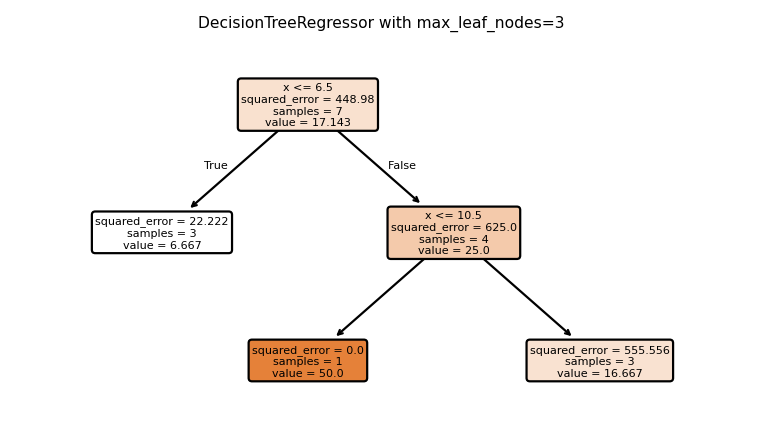

Tree structure:

node 0: split on x <= 6.500000, samples=7, impurity=448.979592, left=1, right=2
node 1: leaf, samples=3, value=6.666667
node 2: split on x <= 10.500000, samples=4, impurity=625.000000, left=3, right=4
node 3: leaf, samples=1, value=50.000000
node 4: leaf, samples=3, value=16.666667


In [16]:
# Fit a tree with pre-pruning so that only one split is made after the root
tree_3_leaves = DecisionTreeRegressor(
    criterion="squared_error",
    max_leaf_nodes=3,
    random_state=0
)
tree_3_leaves.fit(X, y)

plt.figure(figsize=(4.7, 2.7), dpi=160)
plot_tree(
    tree_3_leaves,
    feature_names=["x"],
    filled=True,
    rounded=True,
    impurity=True,
    fontsize=5,
    precision=3
)
plt.title("DecisionTreeRegressor with max_leaf_nodes=3", fontsize=7)
plt.tight_layout(pad=0.5)
plt.show()

tree = tree_3_leaves.tree_

print("Tree structure:\n")
for node_id in range(tree.node_count):
    left = tree.children_left[node_id]
    right = tree.children_right[node_id]
    is_leaf = left == right

    if is_leaf:
        print(
            f"node {node_id}: leaf, "
            f"samples={tree.n_node_samples[node_id]}, "
            f"value={tree.value[node_id][0, 0]:.6f}"
        )
    else:
        print(
            f"node {node_id}: split on x <= {tree.threshold[node_id]:.6f}, "
            f"samples={tree.n_node_samples[node_id]}, "
            f"impurity={tree.impurity[node_id]:.6f}, "
            f"left={left}, right={right}"
        )

### 2.2. Wniosek z eksperymentu w `scikit-learn`

Drzewo z `max_leaf_nodes=3` wykonało:

1. pierwszy split w korzeniu przy progu $x \leq 6.5$,
2. drugi split w **prawym** liściu przy progu $x \leq 10.5$.

To jest zgodne z wcześniejszymi obliczeniami:

- **lokalna minimalizacja RSS** wybrałaby w drugim kroku **lewy** liść,
- **maksymalizacja spadku RSS** wybrałaby w drugim kroku **prawy** liść,
- **minimalizacja całkowitego RSS** także wybrałaby **prawy** liść.

Zatem `DecisionTreeRegressor` z `scikit-learn` **nie** używa kryterium lokalnej minimalizacji RSS rozumianej jako wybór splitu z najmniejszym RSS w nowych dzieciach bez uwzględnienia RSS rodzica.

Wynik eksperymentu jest zgodny z:

- **maksymalizacją spadku RSS**,
- równoważnie: **minimalizacją całkowitego RSS po wykonaniu jednego nowego podziału**.

## 3. Wnioski końcowe

Odpowiedzi na pytania z treści zadania są następujące:

1. **Czy lokalna minimalizacja RSS i maksymalizacja spadku RSS są równoważne?**

   - tak, ale tylko wtedy, gdy `Parent` jest ustalony,
   - nie, jeśli wolno wybierać także `Parent`.

2. **Czy minimalizacja całkowitego RSS pokrywa się z którymś z tych kryteriów?**

   - tak, jest równoważna **maksymalizacji spadku RSS**,
   - nie jest równoważna lokalnej minimalizacji RSS, gdy można wybierać także `Parent`.

3. **Jakie kryterium stosuje `DecisionTreeRegressor` w `scikit-learn`?**

   - eksperyment pokazuje, że wybiera split zgodny z **maksymalizacją spadku RSS**,
   - równoważnie: z **minimalizacją całkowitego RSS po wykonaniu jednego nowego podziału**.

Czyli teoria i eksperyment dają ten sam wynik: `DecisionTreeRegressor` działa zgodnie z kryterium 2, a tym samym także z kryterium 3.